In [1]:
import pandas as pd
import numpy as np
import sqlite3
import requests
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.preprocessing import LabelEncoder, OrdinalEncoder
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler, Normalizer
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from scipy.stats import zscore


In [17]:
customers = pd.read_csv("customers.csv")
transactions = pd.read_json("transactions.json")

conn = sqlite3.connect(":memory:")
with open("products.sql", "r") as f:
    conn.executescript(f.read())

products = pd.read_sql("SELECT * FROM products", conn)

print("Local datasets loaded")

Local datasets loaded


In [19]:
url = "https://dummyjson.com/users"
response = requests.get(url)

if response.status_code == 200:
    users = pd.DataFrame(response.json()["users"])
    users.rename(columns={"id": "customer_id"}, inplace=True)
    print("API loaded")
else:
    users = pd.DataFrame()
    print("API failed")

API loaded


In [21]:
products["price"] = products["price"].apply(lambda x: x if x > 0 else np.nan)
products["category"] = products["category"].fillna("Unknown")
products["stock"] = products["stock"].fillna(products["stock"].median())

# Remove unrealistic values
products = products[products["price"] < 100000]

print("Products cleaned")

Products cleaned


In [23]:
df = transactions.merge(customers, on="customer_id", how="left")
df = df.merge(products, on="product_id", how="left")

if not users.empty:
    df = df.merge(users, on="customer_id", how="left")

print("Data merged")

Data merged


In [25]:
print(df.info())
print(df.describe())
print(df.head())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 43 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   transaction_id  300 non-null    object        
 1   customer_id     300 non-null    int64         
 2   product_id      300 non-null    object        
 3   amount          300 non-null    int64         
 4   payment_mode    285 non-null    object        
 5   date            300 non-null    datetime64[ns]
 6   name            300 non-null    object        
 7   age_x           289 non-null    float64       
 8   gender_x        280 non-null    object        
 9   city            286 non-null    object        
 10  signup_date     300 non-null    object        
 11  income          283 non-null    float64       
 12  product_name    300 non-null    object        
 13  category        300 non-null    object        
 14  price           300 non-null    float64       
 15  stock 

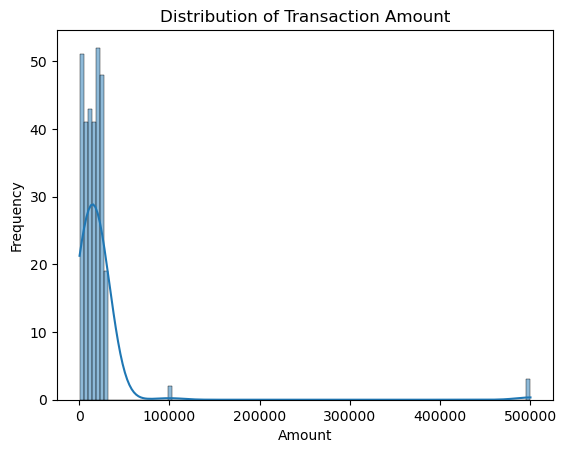

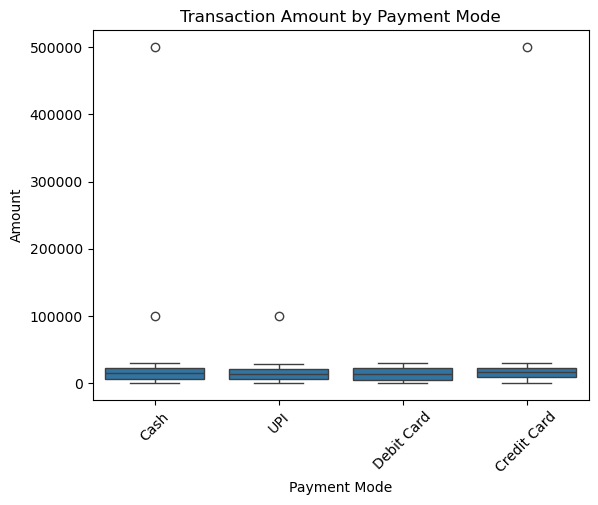

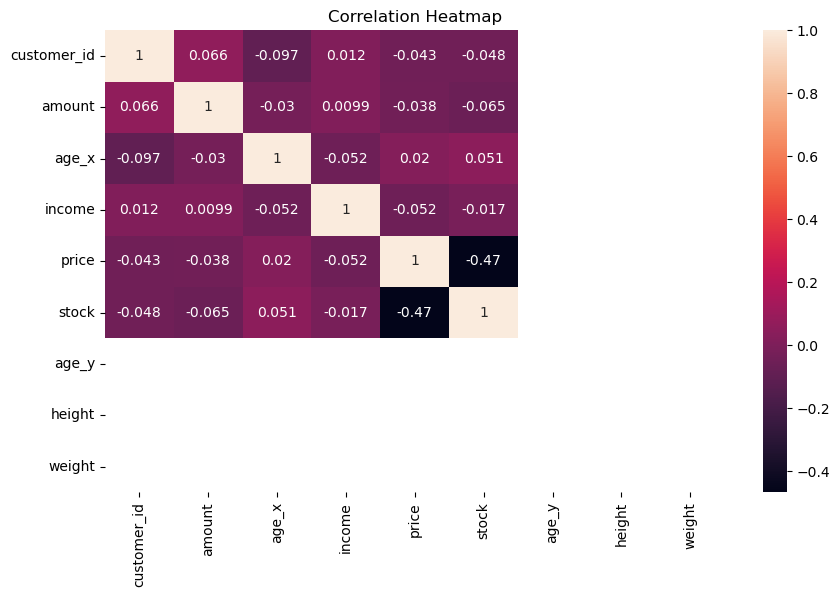

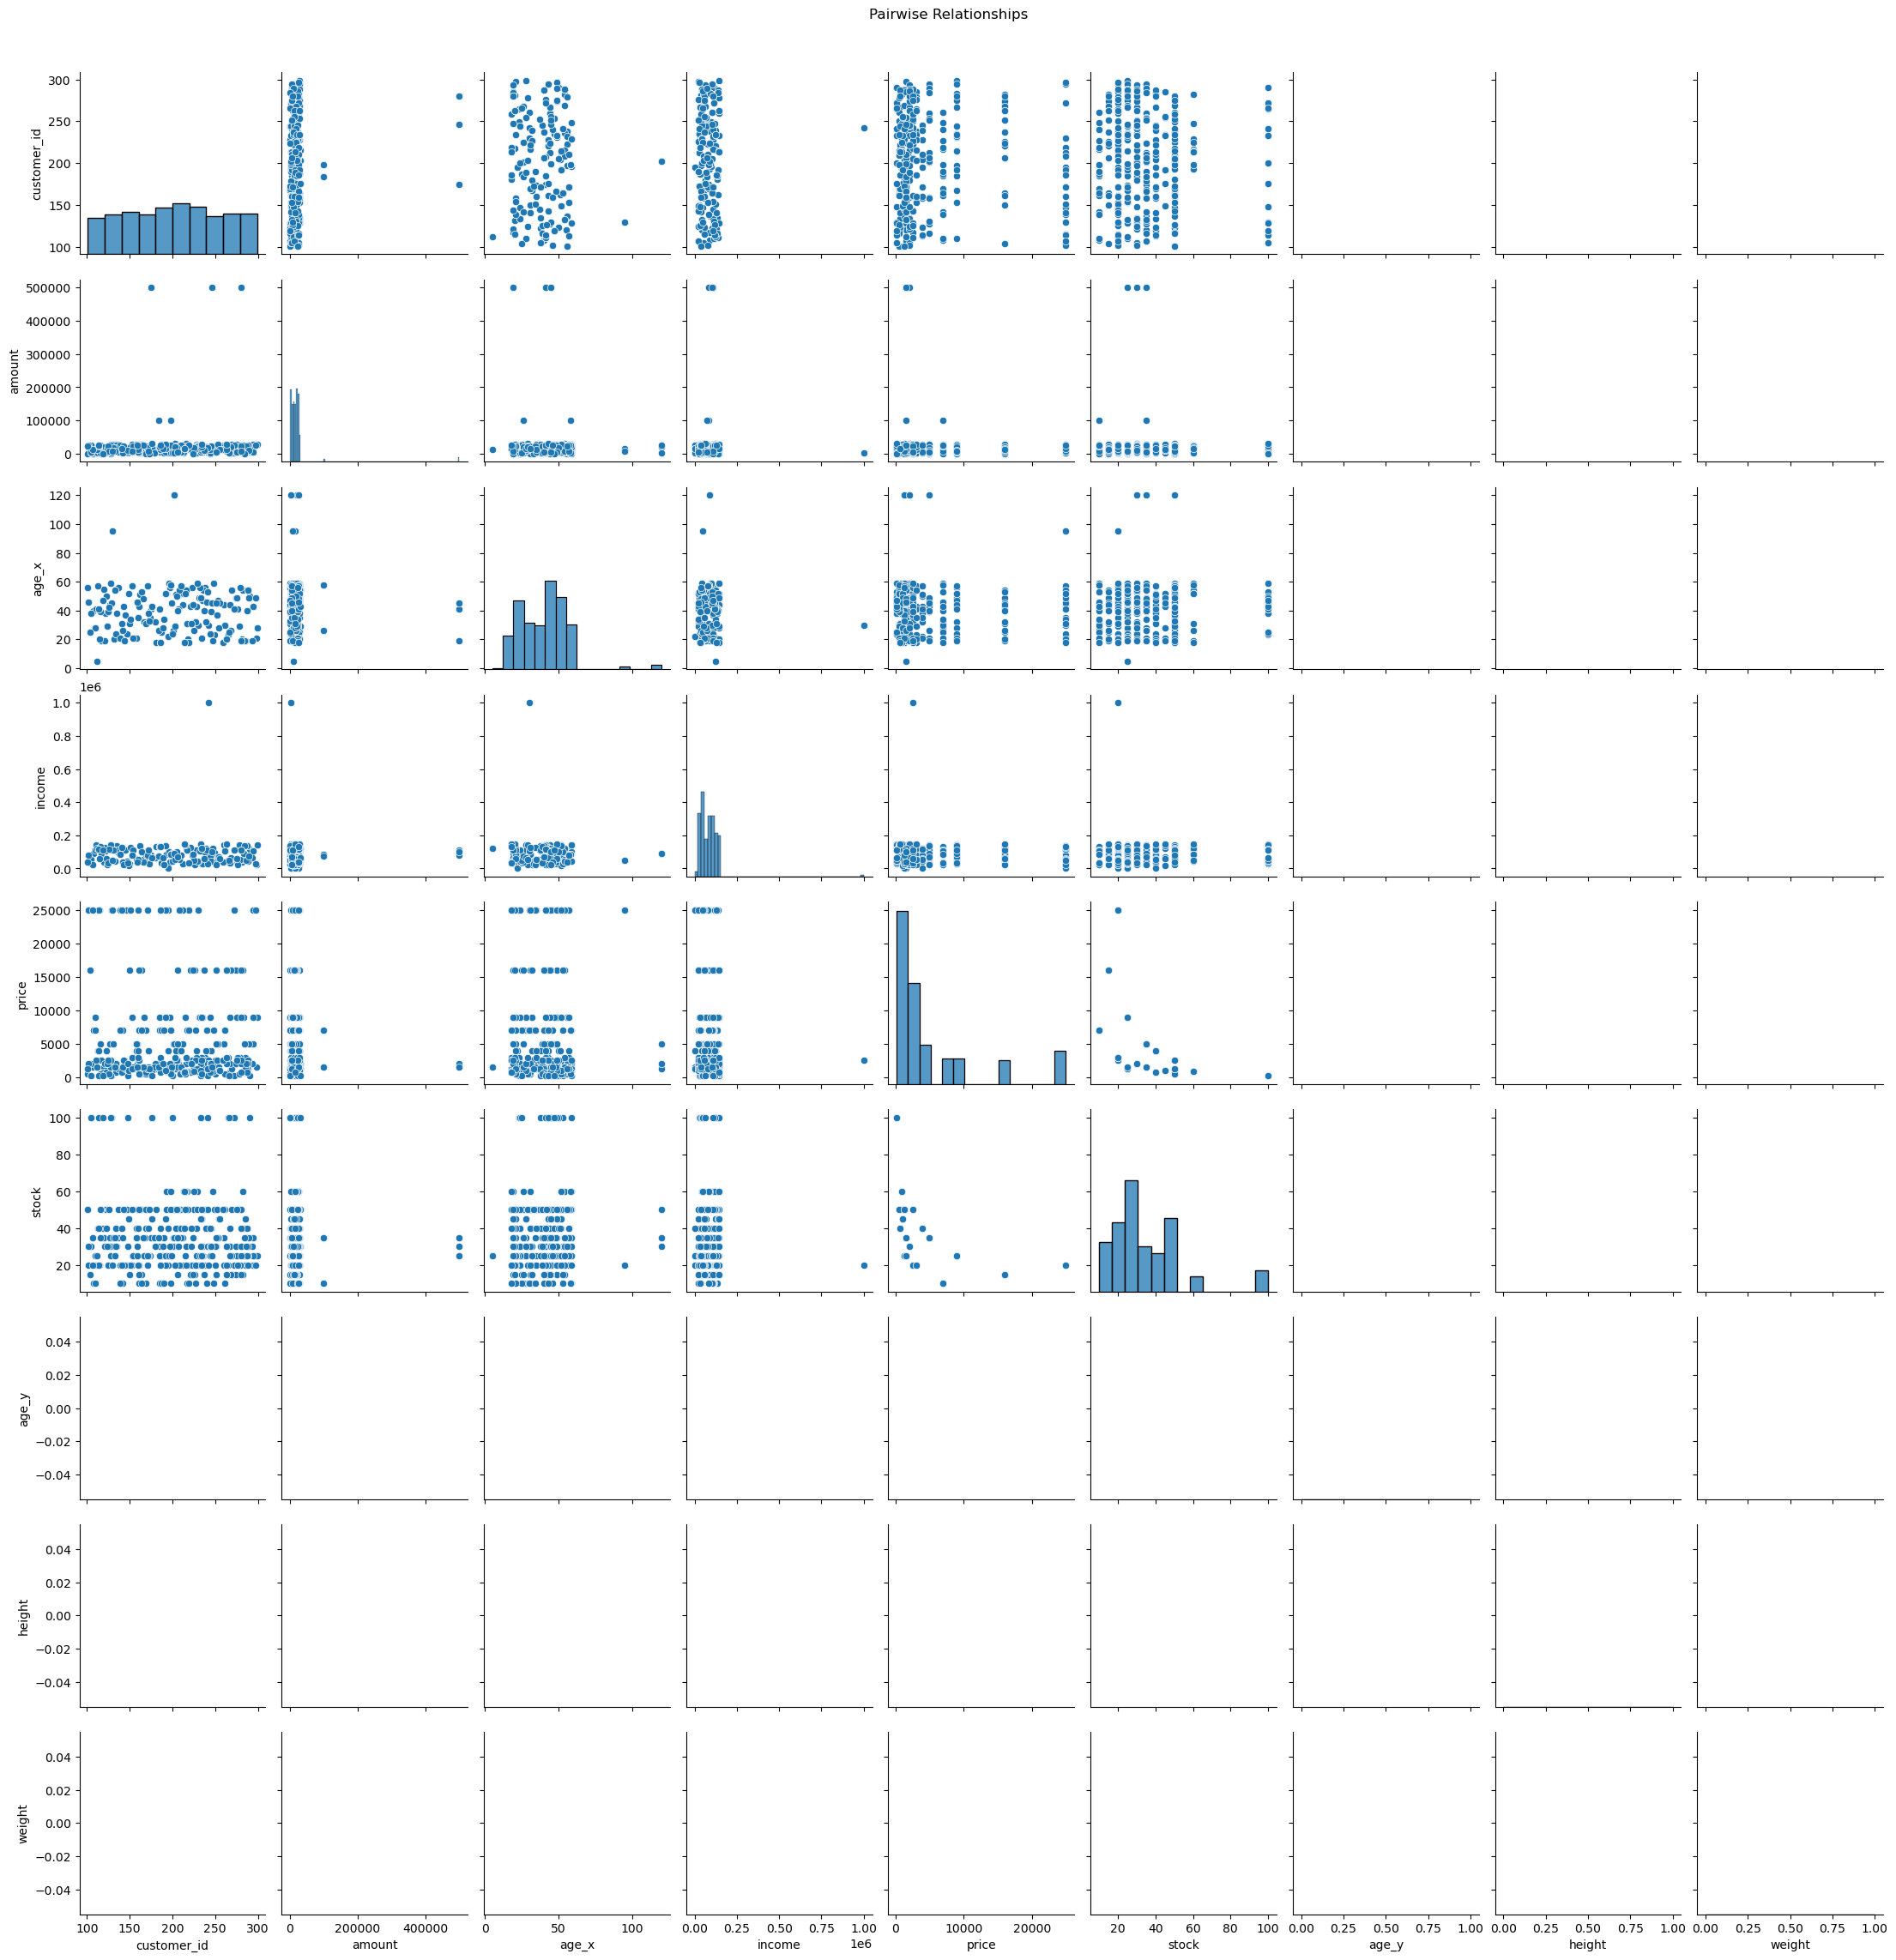

In [27]:
# Univariate
plt.figure()
sns.histplot(df["amount"], kde=True)
plt.title("Distribution of Transaction Amount")
plt.xlabel("Amount")
plt.ylabel("Frequency")
plt.show()

# Bivariate
plt.figure()
sns.boxplot(x="payment_mode", y="amount", data=df)
plt.title("Transaction Amount by Payment Mode")
plt.xlabel("Payment Mode")
plt.ylabel("Amount")
plt.xticks(rotation=45)
plt.show()

# Multivariate
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.title("Correlation Heatmap")
plt.show()

# Pairplot (ADDED)
sns.pairplot(df.select_dtypes(include=np.number))
plt.suptitle("Pairwise Relationships", y=1.02)
plt.show()

In [29]:
# Indicator
df["amount_missing_flag"] = df["amount"].isnull().astype(int)

# Fill categorical
df["payment_mode"] = df["payment_mode"].fillna("Unknown")

# Remove completely empty columns (CRITICAL FIX)
df = df.dropna(axis=1, how="all")

# Recalculate numeric columns AFTER dropping
num_cols = df.select_dtypes(include=np.number).columns

# Simple Imputer
df[num_cols] = SimpleImputer(strategy="median").fit_transform(df[num_cols])

# KNN Imputer
df[num_cols] = KNNImputer().fit_transform(df[num_cols])

# MICE
df[num_cols] = IterativeImputer().fit_transform(df[num_cols])

print("Missing values handled correctly")

Missing values handled correctly


In [31]:
# Z-score (ADDED)
df["zscore"] = zscore(df["amount"])
df = df[df["zscore"] < 3]

# IQR
Q1 = df["amount"].quantile(0.25)
Q3 = df["amount"].quantile(0.75)
IQR = Q3 - Q1

df = df[(df["amount"] > Q1 - 1.5*IQR) & (df["amount"] < Q3 + 1.5*IQR)]

# Winsorization
lower = df["amount"].quantile(0.01)
upper = df["amount"].quantile(0.99)
df["amount"] = df["amount"].clip(lower, upper)

print("Outliers handled")

Outliers handled


In [33]:
df["date"] = pd.to_datetime(df["date"])

df["days_since_last_purchase"] = (
    df["date"].max() - df["date"]
).dt.days

print("Date features created")

Date features created


In [35]:
df["payment_mode_label"] = LabelEncoder().fit_transform(df["payment_mode"])

df[["payment_mode_ordinal"]] = OrdinalEncoder().fit_transform(df[["payment_mode"]])

if "category" in df.columns:
    df = pd.get_dummies(df, columns=["category"], drop_first=True)

print("Encoding done")

Encoding done


In [37]:
df["amount_std"] = StandardScaler().fit_transform(df[["amount"]])
df["amount_minmax"] = MinMaxScaler().fit_transform(df[["amount"]])
df["amount_robust"] = RobustScaler().fit_transform(df[["amount"]])

# Normalizer (ADDED)
df["amount_norm"] = Normalizer().fit_transform(df[["amount"]])

print("Scaling done")

Scaling done


In [39]:
df["purchase_per_day"] = df["amount"] / (df["days_since_last_purchase"] + 1)

df["log_amount"] = np.log1p(df["amount"])
df["sqrt_amount"] = np.sqrt(df["amount"])

df["high_value_customer"] = (df["amount"] > 20000).astype(int)

print("Feature engineering done")

Feature engineering done


In [41]:
df.to_csv("processed_customer_data.csv", index=False)

print("\n FINAL DATA SAVED")


 FINAL DATA SAVED


In [43]:
print("\n===== PROJECT COMPLETED (100%) =====")
print("✔ All data sources integrated")
print("✔ EDA (Uni + Bi + Multi + Pairplot)")
print("✔ Missing values (Indicator + Simple + KNN + MICE)")
print("✔ Outliers (Z-score + IQR + Winsorization)")
print("✔ Encoding (Label + Ordinal + OneHot)")
print("✔ Scaling (Standard + MinMax + Robust + Normalizer)")
print("✔ Feature Engineering")
print("✔ Final dataset ready")


===== PROJECT COMPLETED (100%) =====
✔ All data sources integrated
✔ EDA (Uni + Bi + Multi + Pairplot)
✔ Missing values (Indicator + Simple + KNN + MICE)
✔ Outliers (Z-score + IQR + Winsorization)
✔ Encoding (Label + Ordinal + OneHot)
✔ Scaling (Standard + MinMax + Robust + Normalizer)
✔ Feature Engineering
✔ Final dataset ready
